In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

print("Ready to predict the future.")

Ready to predict the future.


In [2]:
data_dir = '../dataset/archive/2nd_test/2nd_test'
filenames = os.listdir(data_dir)
filenames.sort()

# 1. Calculate Total Life
# There are 984 files. Let's treat each file as one "unit of time" for simplicity.
total_life = len(filenames)
print(f"Total Experiment Duration: {total_life} time steps.")

# 2. Create the Dataset with "Countdown" Targets
X = [] # Raw Signals
y = [] # RUL (Time Left)

# We will skip every 10th file to speed things up, but keep the timeline accurate
step = 10 

print("Building the RUL dataset. Please wait...")

for index in range(0, len(filenames), step):
    # Load file
    filename = filenames[index]
    path = os.path.join(data_dir, filename)
    df = pd.read_csv(path, sep='\t', header=None)
    
    # Feature: Downsample the raw signal (same as Phase 2)
    # We take Bearing 1 (Column 0) only, to keep it simple for now
    signal = df[0].iloc[::10].values 
    
    # TARGET: Calculate Remaining Useful Life (RUL)
    # If index is 0, Time Left = 984
    # If index is 984, Time Left = 0
    time_left = total_life - index
    
    X.append(signal)
    y.append(time_left)

X = np.array(X)
y = np.array(y)

# 3. Scale the Target (y)
# Neural Networks hate big numbers like "984". They love numbers between 0 and 1.
# So we convert "Minutes Left" to "Percentage Left" (1.0 to 0.0)
y_scaled = y / total_life

print("--- Data Ready ---")
print(f"Input Shape (X): {X.shape}") 
print(f"Target Shape (y): {y_scaled.shape}")
print(f"Example Target (First File): {y_scaled[0]:.2f} (Should be ~1.0)")
print(f"Example Target (Last File): {y_scaled[-1]:.2f} (Should be ~0.0)")

Total Experiment Duration: 984 time steps.
Building the RUL dataset. Please wait...
--- Data Ready ---
Input Shape (X): (99, 2048)
Target Shape (y): (99,)
Example Target (First File): 1.00 (Should be ~1.0)
Example Target (Last File): 0.00 (Should be ~0.0)


In [3]:
# 1. Reshape X to fit the CNN (Add the "Channel" dimension)
X = X.reshape(X.shape[0], X.shape[1], 1)

# 2. Split into Train and Test
# We use a random_state so we get the same split every time
X_train, X_test, y_train, y_test = train_test_split(X, y_scaled, test_size=0.2, random_state=42)

print(f"Training Input: {X_train.shape}")
print(f"Test Input: {X_test.shape}")

Training Input: (79, 2048, 1)
Test Input: (20, 2048, 1)


In [4]:
model = models.Sequential()

# Input Layer
model.add(layers.Input(shape=(2048, 1)))

# Feature Extractor (The Scanner)
model.add(layers.Conv1D(filters=32, kernel_size=7, activation='relu'))
model.add(layers.MaxPooling1D(pool_size=4))

model.add(layers.Conv1D(filters=64, kernel_size=7, activation='relu'))
model.add(layers.MaxPooling1D(pool_size=4))

# Flatten
model.add(layers.Flatten())

# The Brain (Regressor)
model.add(layers.Dense(50, activation='relu'))

# OUTPUT LAYER (Critical Change)
# 1 Neuron, Linear Activation (for predicting a continuous number)
model.add(layers.Dense(1, activation='linear'))

# Compile with MSE Loss (Standard for Regression)
model.compile(optimizer='adam', loss='mse', metrics=['mae']) # mae = Mean Absolute Error

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 2042, 32)            │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 510, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 504, 64)             │          14,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 126, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8064)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 50)                  │         403,250 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 417,957 (1.59 MB)

 Trainable params: 417,957 (1.59 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
print("Training the RUL Predictor...")

history = model.fit(X_train, y_train, 
                    epochs=50, 
                    validation_data=(X_test, y_test),
                    batch_size=16) # Smaller batch size for smaller data

print("--- Training Complete ---")

Training the RUL Predictor...
Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - loss: 0.2441 - mae: 0.4028 - val_loss: 0.3001 - val_mae: 0.4542
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.2127 - mae: 0.3837 - val_loss: 0.2127 - val_mae: 0.4043
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.1305 - mae: 0.2876 - val_loss: 0.1613 - val_mae: 0.3345
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0779 - mae: 0.2383 - val_loss: 0.0571 - val_mae: 0.2022
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0333 - mae: 0.1523 - val_loss: 0.0379 - val_mae: 0.1535
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0268 - mae: 0.1399 - val_loss: 0.0185 - val_mae: 0.1121
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0213 - mae: 0.1238 - val_loss: 0.0156 - val_mae: 0.0987
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0138 - mae: 0.0946 - val_loss: 0.0174 - val_mae: 0.1119
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


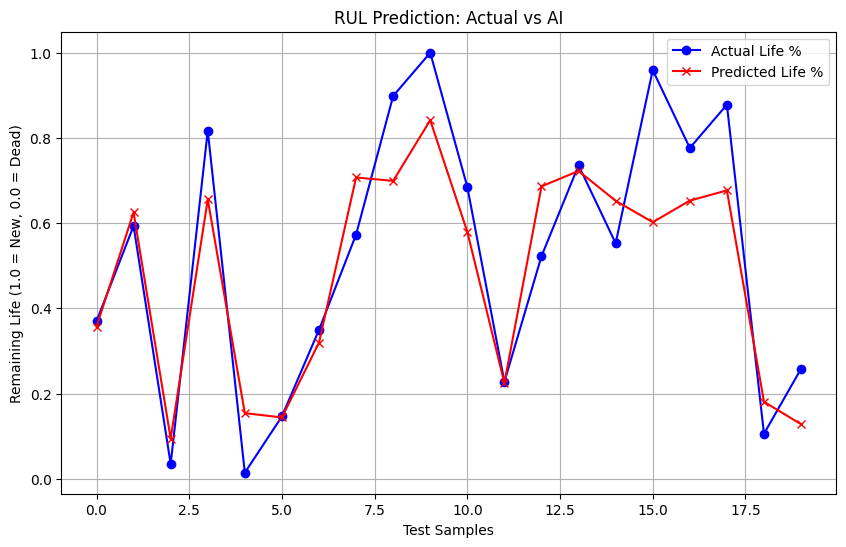

In [6]:
import matplotlib.pyplot as plt

# 1. Make Predictions
predictions = model.predict(X_test)

# 2. Plot Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual Life %', color='blue', marker='o')
plt.plot(predictions, label='Predicted Life %', color='red', marker='x')

plt.title('RUL Prediction: Actual vs AI')
plt.ylabel('Remaining Life (1.0 = New, 0.0 = Dead)')
plt.xlabel('Test Samples')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
# Save the Regression Model
model_filename = '../models/bearing_rul_model.keras'
model.save(model_filename)

print(f"Success! Time-to-Failure Model saved to: {model_filename}")

Success! Time-to-Failure Model saved to: ../models/bearing_rul_model.keras
